# Customer Churn Prediction using Machine Learning

A Machine Learning approach to identify customers likely to churn in telecom industry.

## Problem Statement

Customer churn is one of the biggest challenges faced by telecom companies.
The objective of this project is to build a machine learning model that can predict whether a customer is likely to churn based on demographic and service usage data.
Early identification of churn customers helps companies take proactive retention measures.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('customer_churn.csv')

The dataset has been loaded for further analysis and preprocessing.

## Data Understanding

- The dataset contains customer demographic and service-related information.
- Target variable: Churn
- The goal is to analyze customer behavior and predict churn.

The dataset includes both categorical and numerical features which require preprocessing before model building.


In [3]:
df.shape

(7043, 21)

The dataset contains 7043 rows and 21 columns.

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6607,7242-QZLXF,Male,0,No,Yes,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,25.30,25.3,Yes
4892,8875-AKBYH,Male,1,No,No,20,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,84.35,1745.2,No
1257,0723-VSOBE,Female,1,No,No,45,No,No phone service,DSL,No,...,No,No,No,Yes,One year,No,Electronic check,34.20,1596.6,No
2586,1051-EQPZR,Female,0,Yes,Yes,44,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.60,780.25,No
6883,2133-TSRRM,Female,0,No,Yes,34,Yes,No,Fiber optic,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.35,3688.6,No


The dataset contains both categorical (e.g., gender, Contract) and numerical features (e.g., tenure, MonthlyCharges).

Several categorical columns will require encoding before model training.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


The 'TotalCharges' column is stored as object and needs conversion to numeric type.

In [7]:
# we have to change the data type of total charges to numeric because it is currently an object and we need to perform numerical operations on it. We will use pd.to_numeric() function to convert it to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# We use pd.to_numeric() function to convert the 'TotalCharges' column to numeric data type. The 'errors' parameter is set to 'coerce' which means that any non-numeric values will be replaced with NaN (Not a Number). This allows us to handle any potential issues with non-numeric data in the 'TotalCharges' column and ensures that we can perform numerical operations on it without errors.
# Why we not use astype() function to convert it to numeric? Because as type() function will raise an error if there are any non-numeric values in the column, whereas pd.to_numeric() function will handle it gracefully by replacing non-numeric values with NaN. This makes pd.to_numeric() a better choice for converting columns that may contain non-numeric data.

## Data Cleaning

- Converted TotalCharges column to numeric format.
- Handled missing values.
- Checked for duplicate records.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are 11 missing values in the 'TotalCharges' column.
All other columns contain complete data.

In [10]:
# We have 11 missing values in the 'TotalCharges' column.
# We will fill these missing values with the product of 'MonthlyCharges' and 'tenure' columns, as it is a reasonable assumption that the total charges would be equal to the monthly charges multiplied by the number of months (tenure) the customer has been with the company.
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges']*df['tenure'])

Since TotalCharges is approximately equal to MonthlyCharges multiplied by tenure,
missing values were imputed using this logical relationship.

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

All missing values have been handled successfully. And no duplicated values found in dataset

The dataset is now clean and ready for preprocessing and model building.

## Exploratory Questions to Better Understand the Dataset

In [13]:
#Q1 Extract the 5th column and store it in column_5
column_5 = df[df.columns[4]]
print(column_5)

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041     No
7042     No
Name: Dependents, Length: 7043, dtype: object


In [14]:
#Q2 Extract the 15th column and store it in column_15
column_15 = df[df.columns[14]]
print(column_15)

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040     No
7041     No
7042    Yes
Name: StreamingMovies, Length: 7043, dtype: object


In [15]:
#Q3 Extract all the male senior citizens whose payment method is electronic check and store in senior_male_electronic
senior_male_electronic = df[(df['gender'] == 'Male') & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == 'Electronic check')]
senior_male_electronic

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.30,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.70,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6837,6229-LSCKB,Male,1,No,No,6,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,497.60,No
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,Yes
6914,7142-HVGBG,Male,1,Yes,No,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.00,4414.30,Yes
6967,8739-WWKDU,Male,1,No,No,25,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.50,2196.15,Yes


In [16]:
#Q4. Extract all those customers whose tenure is greater than 70 months or their monthly charges is more than $100 and store the result in‘customer_total_tenure’
customer_total_tenure = df[(df['tenure'] > 70) | (df['MonthlyCharges'] > 100)]
customer_total_tenure




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.10,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No


In [17]:
#Q5 Extract all the customers whose contract is of two years, payment method is mailed check and the value of churn is ‘Yes’ and store the result in ‘two_mail_yes’
two_mail_yes = df[(df['Contract'] == 'Two year') & (df['PaymentMethod'] == 'Mailed check') & (df['Churn'] == 'Yes')]
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.60,Yes
5947,7951-QKZPL,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.50,740.30,Yes
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes


In [18]:
#Q6 Extract 333 random records from the customer_churndataframe and store the result in ‘customer_333’.
customer_333 = df.sample(n=333)
customer_333

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
95,8637-XJIVR,Female,0,No,No,12,Yes,Yes,Fiber optic,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,78.95,927.35,Yes
3468,0247-SLUJI,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.70,19.70,No
3898,2332-TODQS,Female,0,No,No,48,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),25.05,1171.50,No
1925,2123-VSCOT,Female,0,Yes,Yes,59,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),72.10,4194.85,No
6371,1535-VTJOQ,Female,0,No,No,24,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.15,553.00,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,6851-WEFYX,Male,1,Yes,No,35,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,3437.50,No
1190,6807-SIWJI,Male,0,No,No,38,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,One year,Yes,Electronic check,104.85,3887.25,No
1086,8999-BOHSE,Female,1,No,No,11,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),89.70,1047.70,Yes
4826,3389-YGYAI,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,829.55,Yes


In [19]:
#Q7 Get the count of different levels from the ‘Churn’ column
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


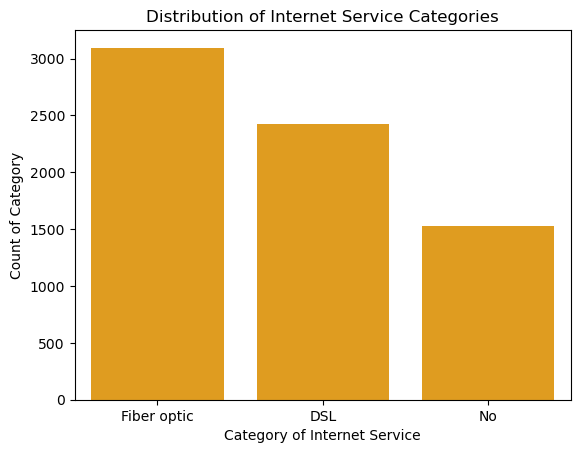

In [20]:
#Q8 Plot a bar graph to show the distribution of different categories in the ‘InternetService’ column
sns.barplot(df['InternetService'].value_counts(),color='orange')
plt.xlabel('Category of Internet Service')
plt.ylabel('Count of Category')
plt.title('Distribution of Internet Service Categories')
plt.show()

### Insight:
Fiber optic internet service is used by the highest number of customers compared to other service types.


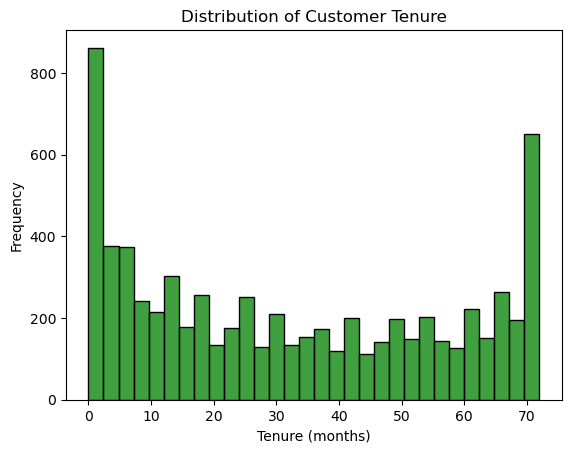

In [21]:
#Q9 Plot a histogram to show the distribution of the ‘tenure’ column    
sns.histplot(df['tenure'], bins=30, color='green')
plt.xlabel('Tenure (months)')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Tenure')
plt.show()

### Insight:
Most customers have lower tenure, indicating a large number of relatively new customers.


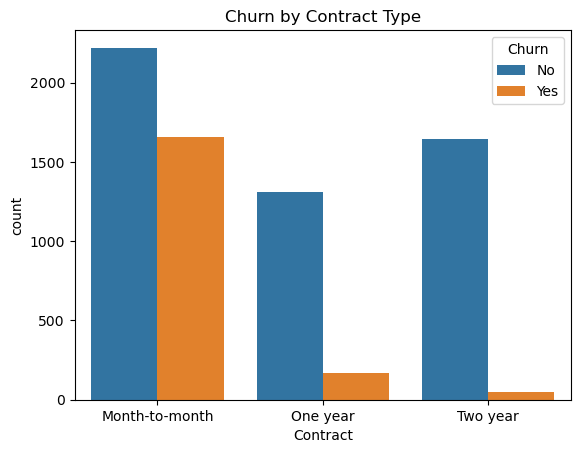

In [22]:
#Q10. How does contract type affect customer churn?
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()




### Insight:
Customers with month-to-month contracts have higher churn rates compared to customers with long-term contracts.


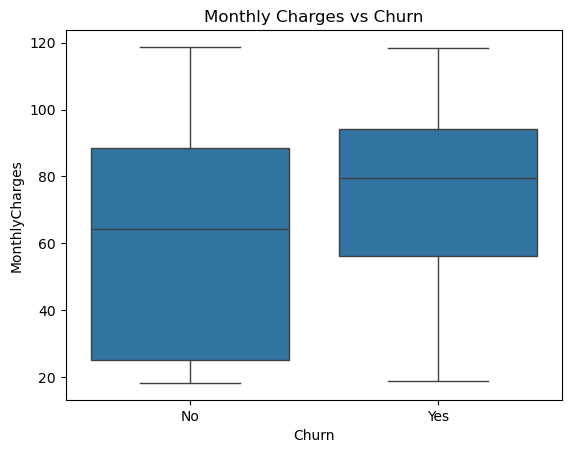

In [23]:
#Q11. Is there a relationship between monthly charges and customer churn?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


### Insight:
Customers who churn tend to have higher monthly charges compared to customers who stay.

# Linear Regression

In [33]:
#Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# a. Divide the dataset into train and test sets in 70:30 ratio.
X = df[['tenure']]  # Independent variable
y = df['MonthlyCharges']  # Dependent variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# b. Build the model on train set and predict the values on test set
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# c. After predicting the values, find the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# d. Find out the error in prediction & store the result in ‘error’
error = y_test - y_pred
print("Prediction Error:", error)
# e. Find the root mean square error.
print("Root Mean Square Error:", rmse)



Prediction Error: 185    -30.306590
2715   -42.185209
3825   -51.475579
1807    21.243410
132    -24.898812
          ...    
5522    15.043410
6377   -10.456590
5500   -12.791303
2392    29.737316
6705   -10.479115
Name: MonthlyCharges, Length: 2113, dtype: float64
Root Mean Square Error: 29.07936015646814


The Linear Regression model is used to predict MonthlyCharges based on tenure. 

The RMSE value indicates how accurately the model performs. 

Lower RMSE means better prediction accuracy.

# Logistic Regression



In [25]:
#Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

# a. Divide the dataset in 65:35 ratio
X = df[['MonthlyCharges']]  # Independent variable
y = df['Churn']  # Dependent variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)

# b. Build the model on train set and predict the values on test set
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

# c. Build the confusion matrix and get the accuracy score
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Accuracy Score:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

# d. Build a multiple logistic regression model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’
x=df[['tenure', 'MonthlyCharges']]  # Independent variables
y=df['Churn']  # Dependent variable
multiple_logistic_model = LogisticRegression()

# e. Divide the dataset in 80:20 ratio
X = df[['tenure', 'MonthlyCharges']]  # Independent variables
y = df['Churn']  # Dependent variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# f. Build the model on train set and predict the values on test set
multiple_logistic_model.fit(X_train, y_train)
y_pred = multiple_logistic_model.predict(X_test)

# g. Build the confusion matrix and get the accuracy score
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("Accuracy Score:", accuracy)

Confusion Matrix:
 [[1797    0]
 [ 669    0]]
Accuracy Score: 0.7287104622871047
Classification Report:
               precision    recall  f1-score   support

          No       0.73      1.00      0.84      1797
         Yes       0.00      0.00      0.00       669

    accuracy                           0.73      2466
   macro avg       0.36      0.50      0.42      2466
weighted avg       0.53      0.73      0.61      2466

Confusion Matrix:
 [[944  92]
 [193 180]]
Accuracy Score: 0.7977288857345636


c:\Users\ronit\anaconda3\ronitana\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronit\anaconda3\ronitana\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronit\anaconda3\ronitana\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Logistic Regression is used for classification problems. 

The model predicts whether a customer will churn or not. 

Model performance is evaluated using confusion matrix and accuracy score. 

Higher accuracy means better prediction.

# Decision tree


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Independent & Dependent variable
X = df[['tenure']]
y = df['Churn']

# 80:20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
dt_model = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
y_pred = dt_model.predict(X_test)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[951  85]
 [257 116]]
Accuracy Score: 0.7572746628814763
Classification Report:
               precision    recall  f1-score   support

          No       0.79      0.92      0.85      1036
         Yes       0.58      0.31      0.40       373

    accuracy                           0.76      1409
   macro avg       0.68      0.61      0.63      1409
weighted avg       0.73      0.76      0.73      1409




Decision Tree is a classification model used to predict customer churn. 
It splits the data based on conditions and evaluates performance using accuracy score. 
Higher accuracy means better prediction.

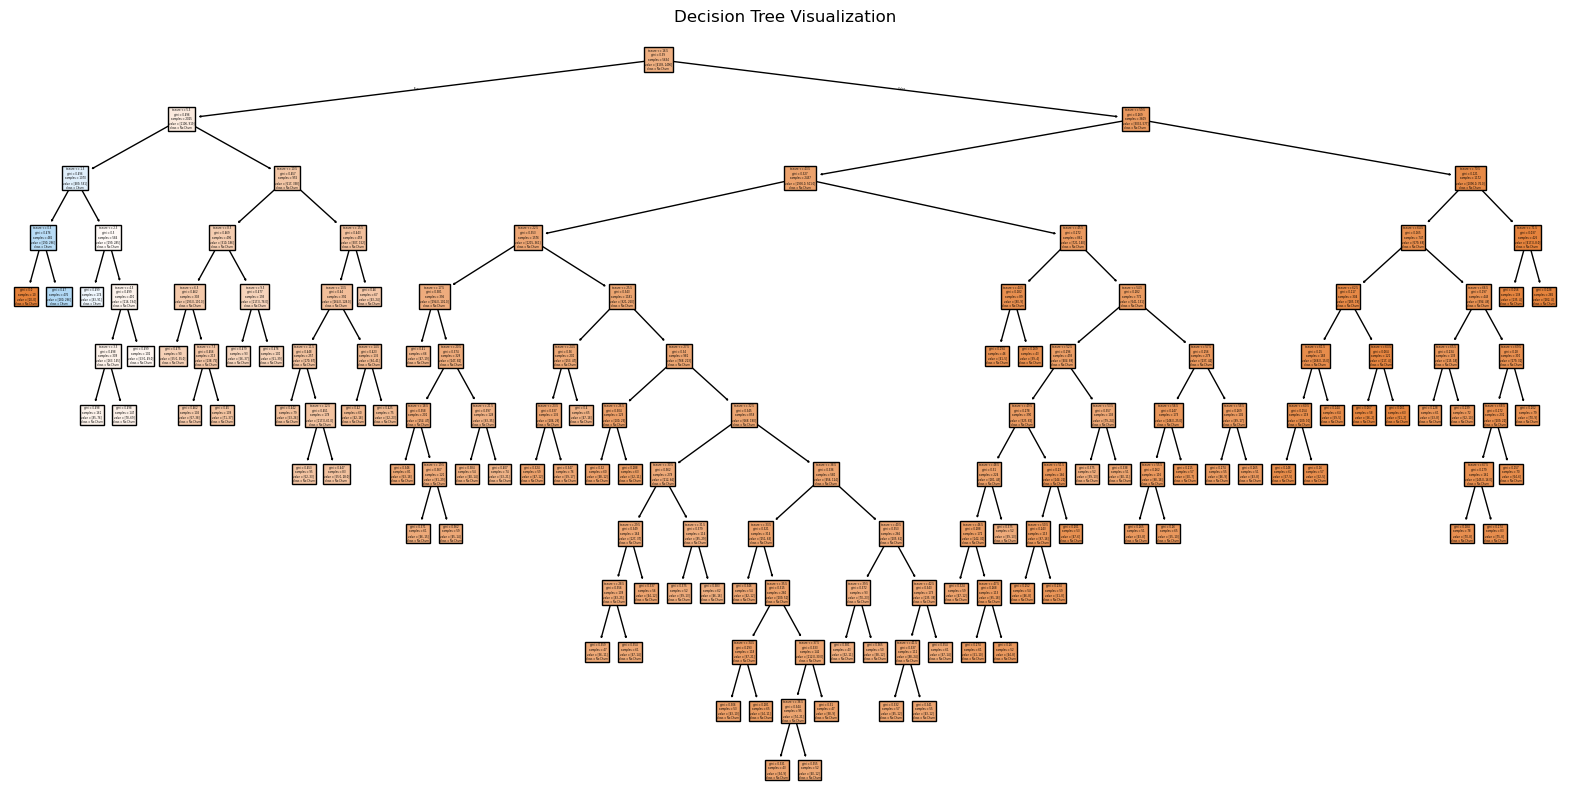

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))   # 50x30 thoda zyada huge ho jata hai
plot_tree(dt_model, 
          filled=True, 
          feature_names=['tenure'], 
          class_names=['No Churn', 'Churn'])

plt.title('Decision Tree Visualization')
plt.show()